In [464]:
import os
import gc
import zarr
import yaml
import json
import numba
import numpy as np
import polars as pl
import pandas as pd
from tqdm import tqdm
import statsmodels.api as sm

from anngeno import AnnGeno
import multiprocessing

from plotnine import *
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

num_cores = multiprocessing.cpu_count()
print(num_cores)

32


In [465]:
# Configuration and paths
corr_method = 'spearman'
trait_type = 'quantitative'
eur_samples_path = '/home/dnanexus/data_dir/unrelated_cauc_samples_3rd_degree.csv'

mac = 1000
# maf=1e-3
# n = !wc -l $eur_samples_path
# n_eur = int(n[0].split(' ')[0])
# mac = maf*(2*n_eur)
# mac


In [466]:
config_path = f'/home/dnanexus/ukbgym/config.yaml'
with open(config_path) as f:
    config = yaml.safe_load(f)

# Collect annotation categories
all_annotation_list = []
rare_variant_annotations_dict = config.get("rare_variant_annotations")
if rare_variant_annotations_dict:
    for category in rare_variant_annotations_dict.values():
        all_annotation_list.extend(category)


In [467]:
appv = pl.read_parquet("/home/dnanexus/data_dir/avg_pheno_per_var_quantitative_EUR_dmsCoding.parquet")
appv = appv.filter(pl.col('n_individuals')<=mac)
appv

id,phenotype,n_individuals,mean_pheno_value,std_pheno_value
str,str,u32,f32,f32
"""chr1:1327326:G:A""","""red_blood_cell_erythrocyte_dis…",1,-0.391999,null
"""chr1:1333534:G:A""","""red_blood_cell_erythrocyte_dis…",3,-0.802695,1.69287
"""chr1:1334123:C:G""","""mean_platelet_thrombocyte_volu…",375,0.011048,0.877053
"""chr1:1340109:T:C""","""mean_platelet_thrombocyte_volu…",26,-0.294736,0.983572
"""chr1:8356202:C:T""","""mean_platelet_thrombocyte_volu…",13,-0.234435,0.737698
…,…,…,…,…
"""chr22:40869007:T:C""","""red_blood_cell_erythrocyte_dis…",1,-0.631422,null
"""chr22:41177819:A:T""","""mean_corpuscular_haemoglobin_c…",1,0.663226,null
"""chr22:41155038:G:A""","""mothers_age_at_death_int""",1,0.046959,null


In [468]:
# Beltran et al. 2025
# exp_df = pl.read_parquet("/home/dnanexus/data_dir/exp_data/250904_Beltran_447aPCA.parquet").rename({
#     'dms_type': 'annotation',
#     'dms_score': 'annotation_score'
# })
# exp_annos = [
#     'fitness',
#     'scaled_fitness',
#     # 'fitness_sigma',
#     # 'scaled_fitness_sigma',
#     'ESM1v_domain',
#     'RaSP',
#     'ddmut',
#     'FoldX',
#     'rsasa',
#     'thermoMPNN',
#     'ESM1v_full-length',
#     # 'AlphaMissense',
#     # 'EVE',
#     # 'Tranception',
#     # 'EVE_domain'
#     ]
# exp_df = exp_df.filter(pl.col('annotation').is_in(exp_annos)).drop_nulls()

exp_df = pl.read_parquet("/home/dnanexus/data_dir/exp_data/250717_proteinGym_SNP_96DMS.parquet").rename({
    'dms_type': 'annotation',
    'dms_score': 'annotation_score'
})

exp_annos = ['HXK4_HUMAN_Gersing_2022_activity', 'HXK4_HUMAN_Gersing_2023_abundance']

exp_df = exp_df.filter(
    pl.col('annotation').is_in(exp_annos)
).with_columns(
    pl.col('annotation_score').cast(pl.Float32),
).drop_nulls()

# [mutant, region] combinations where all of the exp_annos are present
valid_combos = (
    exp_df
    .group_by(["mutant", "region"])
    .agg(pl.col("annotation").n_unique().alias("n_annos"))
    .filter(pl.col("n_annos") == len(exp_annos))
    .select(["mutant", "region"])
)

# Join back if you want the filtered full dataset
exp_df = exp_df.join(valid_combos, on=["mutant", "region"])
exp_df

mutant,mutated_sequence,annotation_score,dms_score_bin,protein_name,file_name,gene_name,gene_type,gene_id,region,annotation
str,str,f32,i64,str,str,str,str,str,str,str
"""A10C""","""MLDDRARMECAKKEKVEQILAEFQLQEEDL…",1.823896,1,"""HXK4""","""HXK4_HUMAN_Gersing_2022_activi…","""GCK""","""protein_coding""","""ENSG00000106633""","""ENSG00000106633""","""HXK4_HUMAN_Gersing_2022_activi…"
"""A10D""","""MLDDRARMEDAKKEKVEQILAEFQLQEEDL…",0.580222,1,"""HXK4""","""HXK4_HUMAN_Gersing_2022_activi…","""GCK""","""protein_coding""","""ENSG00000106633""","""ENSG00000106633""","""HXK4_HUMAN_Gersing_2022_activi…"
"""A10E""","""MLDDRARMEEAKKEKVEQILAEFQLQEEDL…",0.828439,1,"""HXK4""","""HXK4_HUMAN_Gersing_2022_activi…","""GCK""","""protein_coding""","""ENSG00000106633""","""ENSG00000106633""","""HXK4_HUMAN_Gersing_2022_activi…"
"""A10F""","""MLDDRARMEFAKKEKVEQILAEFQLQEEDL…",2.049407,1,"""HXK4""","""HXK4_HUMAN_Gersing_2022_activi…","""GCK""","""protein_coding""","""ENSG00000106633""","""ENSG00000106633""","""HXK4_HUMAN_Gersing_2022_activi…"
"""A10G""","""MLDDRARMEGAKKEKVEQILAEFQLQEEDL…",1.026044,1,"""HXK4""","""HXK4_HUMAN_Gersing_2022_activi…","""GCK""","""protein_coding""","""ENSG00000106633""","""ENSG00000106633""","""HXK4_HUMAN_Gersing_2022_activi…"
…,…,…,…,…,…,…,…,…,…,…
"""Y61R""","""MLDDRARMEAAKKEKVEQILAEFQLQEEDL…",0.613017,1,"""HXK4""","""HXK4_HUMAN_Gersing_2023_abunda…","""GCK""","""protein_coding""","""ENSG00000106633""","""ENSG00000106633""","""HXK4_HUMAN_Gersing_2023_abunda…"
"""Y61S""","""MLDDRARMEAAKKEKVEQILAEFQLQEEDL…",0.979731,1,"""HXK4""","""HXK4_HUMAN_Gersing_2023_abunda…","""GCK""","""protein_coding""","""ENSG00000106633""","""ENSG00000106633""","""HXK4_HUMAN_Gersing_2023_abunda…"
"""Y61T""","""MLDDRARMEAAKKEKVEQILAEFQLQEEDL…",0.372506,0,"""HXK4""","""HXK4_HUMAN_Gersing_2023_abunda…","""GCK""","""protein_coding""","""ENSG00000106633""","""ENSG00000106633""","""HXK4_HUMAN_Gersing_2023_abunda…"


In [469]:
anno = pl.read_parquet("/home/dnanexus/data_dir/dms_coding.ag/annotations.parquet")
existing_annos = [c for c in all_annotation_list if c in anno.columns]

anno = anno.with_columns(
    (pl.col('consequence_missense_variant') == 1)
).select(
    set(['id', 'mutant', 'region']).union(set(existing_annos))
).filter(
    pl.col('id').is_in(appv['id'].unique())
)

val_ids = anno[['mutant', 'id', 'region']].unique().join(exp_df[['mutant', 'region']].unique(), on=['mutant', 'region'], how='inner')
val_ids

/tmp/ipykernel_760855/2494122043.py:8: DeprecationWarning: `is_in` with a collection of the same datatype is ambiguous and deprecated.
Please use `implode` to return to previous behavior.

See https://github.com/pola-rs/polars/issues/22149 for more information.


mutant,id,region
str,str,str
"""E319Q""","""chr7:44146527:C:G""","""ENSG00000106633"""
"""A188T""","""chr7:44149986:C:T""","""ENSG00000106633"""
"""G261R""","""chr7:44147732:C:T""","""ENSG00000106633"""
"""G464D""","""chr7:44145143:C:T""","""ENSG00000106633"""
"""M235L""","""chr7:44147810:T:A""","""ENSG00000106633"""
…,…,…
"""C457Y""","""chr7:44145164:C:T""","""ENSG00000106633"""
"""V182M""","""chr7:44150004:C:T""","""ENSG00000106633"""
"""T65N""","""chr7:44153315:G:T""","""ENSG00000106633"""


In [470]:
melted_anno = anno.join(
    val_ids, 
    on=['mutant', 'id', 'region'], 
    how='inner'
).unpivot(
    index=["id", "mutant", "region"],
    on=existing_annos,
    variable_name="annotation",
    value_name="annotation_score"
).with_columns(
    pl.col("annotation_score").cast(pl.Float32),
    pl.col("region").cast(pl.Utf8),
).join(
    exp_df[['mutant', 'region']].unique(), 
    on=['mutant', 'region'], 
    how='inner'
)

exp_df_subset = exp_df.join(val_ids.unique(), on=['mutant', 'region'], how='inner')[melted_anno.columns]
melted_anno = pl.concat([melted_anno, exp_df_subset])

melted_anno

id,mutant,region,annotation,annotation_score
str,str,str,str,f32
"""chr7:44146484:C:T""","""R333H""","""ENSG00000106633""","""cadd_raw""",4.789699
"""chr7:44146484:C:T""","""R333H""","""ENSG00000106633""","""am_pathogenicity""",0.288
"""chr7:44146484:C:T""","""R333H""","""ENSG00000106633""","""gpn_score""",-7.36
"""chr7:44146484:C:T""","""R333H""","""ENSG00000106633""","""verphylop""",3.073
"""chr7:44146484:C:T""","""R333H""","""ENSG00000106633""","""zooverphylop""",6.909
…,…,…,…,…
"""chr7:44152378:C:A""","""V86L""","""ENSG00000106633""","""HXK4_HUMAN_Gersing_2023_abunda…",0.869834
"""chr7:44152363:C:T""","""V91M""","""ENSG00000106633""","""HXK4_HUMAN_Gersing_2023_abunda…",0.976518
"""chr7:44152312:A:G""","""Y108H""","""ENSG00000106633""","""HXK4_HUMAN_Gersing_2023_abunda…",0.489184


In [471]:
a = pl.read_parquet('/home/dnanexus/data_dir/genebass_continuous_associations_ukbbgym.pq').with_columns(
    (pl.col('description').str.replace_all(r"\(", "").str.replace_all(r"\)", "").str.replace_all(' ', '_').str.to_lowercase() + '_int').alias('phenotype'),
    pl.col('gene_id').alias('region'),
    pl.col('gene_symbol').alias('gene_name')
).filter(
    (pl.col('annotation').str.contains('pLoF')) &
    # (pl.col('annotation') == 'pLoF') &
    (pl.col('phenotype').is_in(appv['phenotype'].unique())) &
    (pl.col('region').is_in(anno['region'].unique()))
)

# Keep the top hit per gene
# a = a.sort("Pvalue").unique(subset=["region"], keep="first")

gene_trait_df = a[['region', 'gene_id', 'gene_name', 'phenotype', 'trait_type']].unique()

# Get beta directions
plof = pl.read_parquet('/home/dnanexus/data_dir/rvat_EUR_500k_regenie.parquet').with_columns(
    (pl.col('trait') + '_int').alias('phenotype'),
    pl.col('gene_id').alias('region')
)
gene_trait_df = gene_trait_df.join(plof[['region', 'phenotype', 'beta']], on=['region', 'phenotype'], how='inner')

gene_trait_df

/tmp/ipykernel_760855/327114618.py:5: DeprecationWarning: `is_in` with a collection of the same datatype is ambiguous and deprecated.
Please use `implode` to return to previous behavior.

See https://github.com/pola-rs/polars/issues/22149 for more information.


region,gene_id,gene_name,phenotype,trait_type,beta
str,str,str,str,str,f64
"""ENSG00000141458""","""ENSG00000141458""","""NPC1""","""lymphocyte_percentage_int""","""continuous""",-0.218614
"""ENSG00000179218""","""ENSG00000179218""","""CALR""","""lymphocyte_percentage_int""","""continuous""",-0.335786
"""ENSG00000143627""","""ENSG00000143627""","""PKLR""","""red_blood_cell_erythrocyte_cou…","""continuous""",-0.251586
"""ENSG00000244734""","""ENSG00000244734""","""HBB""","""red_blood_cell_erythrocyte_cou…","""continuous""",2.1052
"""ENSG00000141458""","""ENSG00000141458""","""NPC1""","""red_blood_cell_erythrocyte_cou…","""continuous""",0.124363
…,…,…,…,…,…
"""ENSG00000163554""","""ENSG00000163554""","""SPTA1""","""reticulocyte_count_int""","""continuous""",0.801084
"""ENSG00000244734""","""ENSG00000244734""","""HBB""","""reticulocyte_count_int""","""continuous""",1.04184
"""ENSG00000179218""","""ENSG00000179218""","""CALR""","""reticulocyte_count_int""","""continuous""",0.272931


In [472]:
anno_flt = melted_anno.filter(
    pl.col('region').is_in(gene_trait_df['region'].unique())
).drop([c for c in anno.columns if 'is_nan' in c])

appv_flt = appv.filter(
    pl.col('id').is_in(anno_flt['id'].unique())
).drop('std_pheno_value').drop_nulls()

print(anno_flt.shape, appv_flt.shape)

/tmp/ipykernel_760855/2529300033.py:1: DeprecationWarning: `is_in` with a collection of the same datatype is ambiguous and deprecated.
Please use `implode` to return to previous behavior.

See https://github.com/pola-rs/polars/issues/22149 for more information.
/tmp/ipykernel_760855/2529300033.py:5: DeprecationWarning: `is_in` with a collection of the same datatype is ambiguous and deprecated.
Please use `implode` to return to previous behavior.

See https://github.com/pola-rs/polars/issues/22149 for more information.


(1494, 5) (18793, 4)


In [473]:
# Join df all the dataframes with pairs to restrict to valid (gene_id, phenotype)
# pheno_anno = appv_flt.join(anno_flt, on='id')
# pheno_anno = pheno_anno.join(gene_trait_df, on=['region', 'phenotype'])
pheno_anno = (
    appv_flt.lazy()
    .join(anno_flt.lazy(), on="id", how="inner")
    .join(gene_trait_df.lazy(), on=["region", "phenotype"], how="inner")
    .collect(engine='streaming')
)

print(pheno_anno.shape)

# Rank the mean phenotype values and annotation scores
rank_expressions = [
    pl.col(c)
    .rank("ordinal")
    .over(["region", "phenotype", "annotation"])
    .alias(f"{c}_rank")
    for c in ['mean_pheno_value', 'annotation_score']
]

# Apply the window expressions with .with_columns()
pheno_anno = pheno_anno.with_columns(rank_expressions)
pheno_anno

(7308, 12)


id,phenotype,n_individuals,mean_pheno_value,mutant,region,annotation,annotation_score,gene_id,gene_name,trait_type,beta,mean_pheno_value_rank,annotation_score_rank
str,str,u32,f32,str,str,str,f32,str,str,str,f64,u32,u32
"""chr7:44145162:T:C""","""glucose_int""",1,1.412056,"""K458E""","""ENSG00000106633""","""cadd_raw""",5.390146,"""ENSG00000106633""","""GCK""","""continuous""",1.62192,112,130
"""chr7:44145162:T:C""","""glucose_int""",1,1.412056,"""K458E""","""ENSG00000106633""","""am_pathogenicity""",0.3955,"""ENSG00000106633""","""GCK""","""continuous""",1.62192,112,87
"""chr7:44145162:T:C""","""glucose_int""",1,1.412056,"""K458E""","""ENSG00000106633""","""gpn_score""",-9.12,"""ENSG00000106633""","""GCK""","""continuous""",1.62192,112,47
"""chr7:44145162:T:C""","""glucose_int""",1,1.412056,"""K458E""","""ENSG00000106633""","""verphylop""",5.403,"""ENSG00000106633""","""GCK""","""continuous""",1.62192,112,87
"""chr7:44145162:T:C""","""glucose_int""",1,1.412056,"""K458E""","""ENSG00000106633""","""zooverphylop""",6.282,"""ENSG00000106633""","""GCK""","""continuous""",1.62192,112,74
…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""chr7:44146479:C:G""","""ldl_direct_int""",3,0.650486,"""V335L""","""ENSG00000106633""","""verphylop""",1.824,"""ENSG00000106633""","""GCK""","""continuous""",-0.891296,135,33
"""chr7:44146479:C:G""","""ldl_direct_int""",3,0.650486,"""V335L""","""ENSG00000106633""","""zooverphylop""",8.644,"""ENSG00000106633""","""GCK""","""continuous""",-0.891296,135,111
"""chr7:44146479:C:G""","""ldl_direct_int""",3,0.650486,"""V335L""","""ENSG00000106633""","""relative_cds_position""",0.72,"""ENSG00000106633""","""GCK""","""continuous""",-0.891296,135,110


In [474]:
correlation_df = (
    pheno_anno
    .group_by(["region", "gene_name", "phenotype", "annotation"])
    .agg(
        pl.col("id").count().alias("n_variants"),
        pl.corr(pl.col("mean_pheno_value_rank"), pl.col("annotation_score")).alias("correlation")
    ).with_columns(
        pl.col("correlation").abs().alias("abs_corr"),
    )
)

# Check if the variant counts are consistent within each (region, phenotype) pair
inconsistent = (
    correlation_df
    .group_by(["region", "phenotype"])
    .agg(pl.col("n_variants").n_unique().alias("n_variants_unique"))
    .filter(pl.col("n_variants_unique") > 1)
)
print(f"Inconsistent (region, phenotype) pairs: {inconsistent.shape[0]}")

# correlation_df = correlation_df.filter(pl.col('n_variants')>=10)
correlation_df

Inconsistent (region, phenotype) pairs: 0


region,gene_name,phenotype,annotation,n_variants,correlation,abs_corr
str,str,str,str,u32,f64,f64
"""ENSG00000106633""","""GCK""","""apolipoprotein_b_int""","""HXK4_HUMAN_Gersing_2022_activi…",164,0.080205,0.080205
"""ENSG00000106633""","""GCK""","""glucose_int""","""relative_cds_position""",155,0.147904,0.147904
"""ENSG00000106633""","""GCK""","""ldl_direct_int""","""HXK4_HUMAN_Gersing_2022_activi…",164,0.089535,0.089535
"""ENSG00000106633""","""GCK""","""glycated_haemoglobin_hba1c_int""","""relprotpos""",165,0.111077,0.111077
"""ENSG00000106633""","""GCK""","""cholesterol_int""","""verphylop""",164,-0.037155,0.037155
…,…,…,…,…,…,…
"""ENSG00000106633""","""GCK""","""ldl_direct_int""","""relative_cds_position""",164,0.003563,0.003563
"""ENSG00000106633""","""GCK""","""glucose_int""","""HXK4_HUMAN_Gersing_2022_activi…",155,-0.372125,0.372125
"""ENSG00000106633""","""GCK""","""cholesterol_int""","""relative_cds_position""",164,-0.023251,0.023251


/tmp/ipykernel_760855/4104778986.py:15: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.


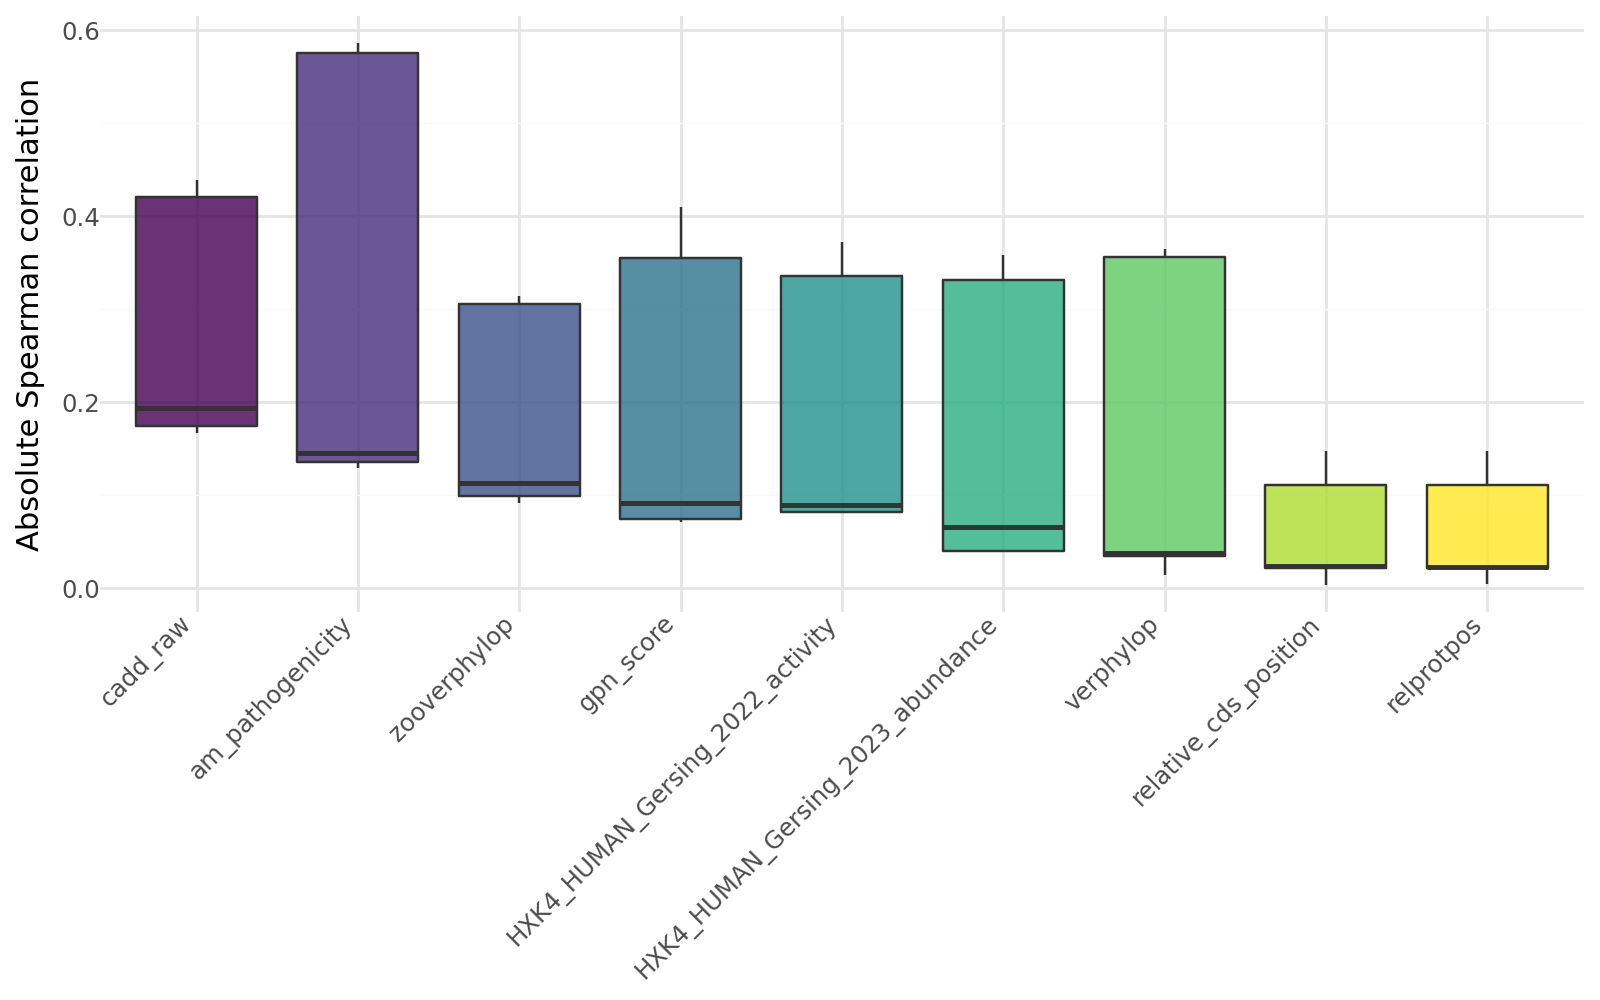

In [475]:


med_df = correlation_df.drop_nans().group_by("annotation").agg([
    pl.col("abs_corr").median().alias("median_abs_corr"),
])

corr_pd = med_df.join(correlation_df, on='annotation').to_pandas()

corr_pd['annotation'] = pd.Categorical(
    corr_pd['annotation'],
    categories=corr_pd.sort_values('median_abs_corr', ascending=False)['annotation'].unique(),
    ordered=True
)

# Define colors
order = corr_pd['annotation'].cat.categories.to_list()
cmap = plt.cm.get_cmap("viridis", len(order))
color_dict = dict(zip(order, [mcolors.to_hex(cmap(i)) for i in range(len(order))]))

# Plot
(
    ggplot(corr_pd, aes(x='annotation', y='abs_corr', fill='annotation')) +
    geom_boxplot(alpha=0.8) +
    theme_minimal() +
    # scale_y_sqrt(limits=[0, 0.6], breaks=[b*0.1 for b in range(7)]) +
    scale_fill_manual(values=color_dict) +
    labs(
        x='',
        y='Absolute Spearman correlation'
    ) +
    theme(
        figure_size=(8, 5),
        legend_position='none',
        axis_text_x=element_text(rotation=45, hjust=1)
    )
)

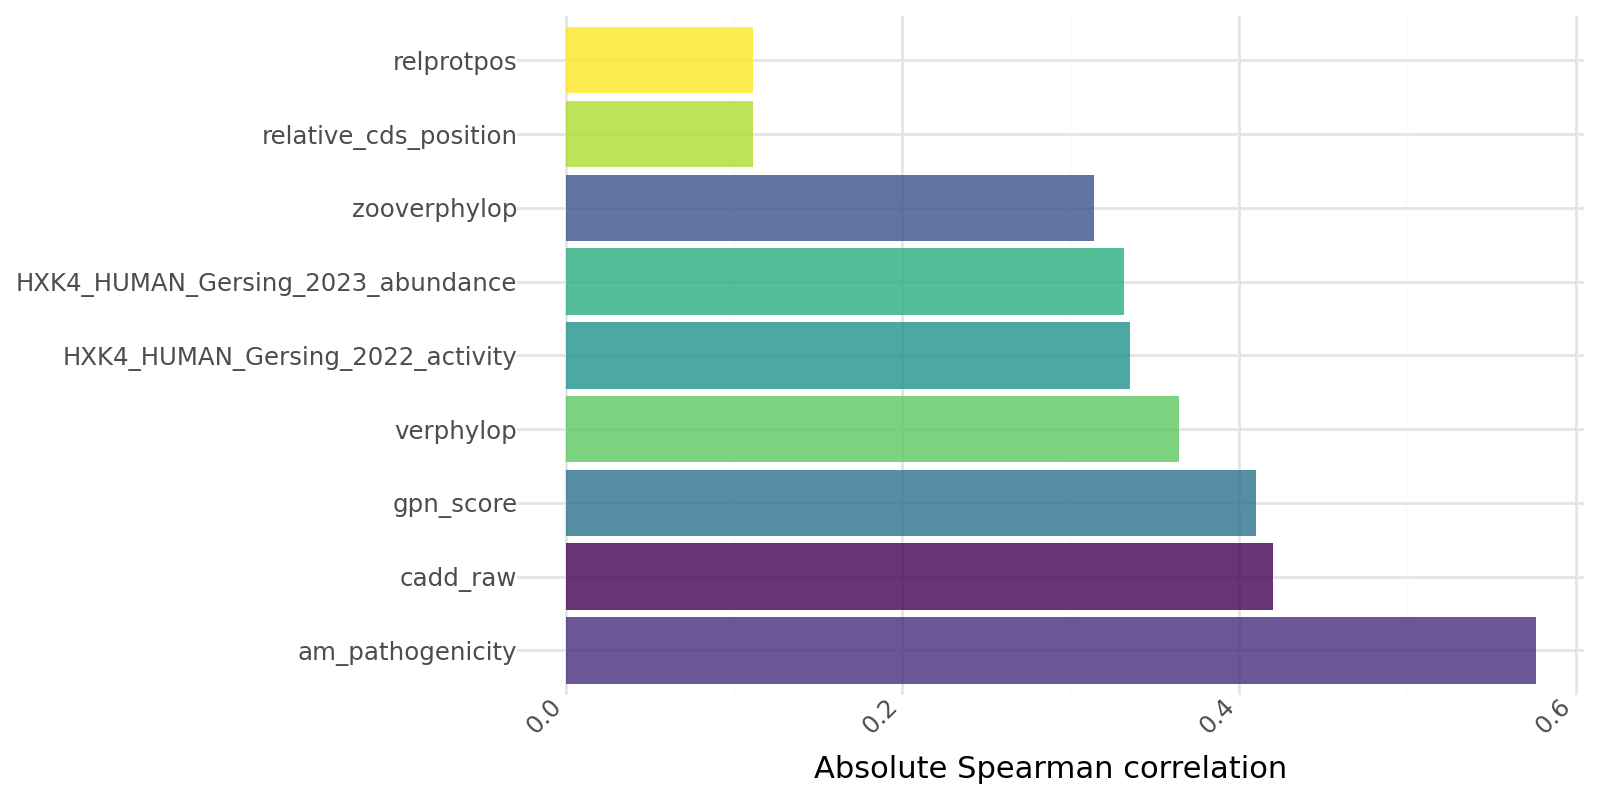

In [476]:
bar_df = correlation_df.filter(pl.col('phenotype')=='glycated_haemoglobin_hba1c_int')
bar_df = bar_df.sort('abs_corr', descending=True).with_columns(
    pl.col('annotation').cast(pl.Categorical).alias('annotation')
).to_pandas()
bar_df['annotation'] = bar_df['annotation'].cat.reorder_categories(bar_df['annotation'])

# Plot
(
    ggplot(bar_df, aes(x='annotation', y='abs_corr', fill='annotation')) +
    geom_col(alpha=0.8) +
    theme_minimal() +
    scale_fill_manual(values=color_dict) +
    labs(
        x='',
        y='Absolute Spearman correlation'
    ) +
    coord_flip() +
    theme(
        figure_size=(8, 4),
        legend_position='none',
        axis_text_x=element_text(rotation=45, hjust=1)
    )
)

## Single gene-trait association plot

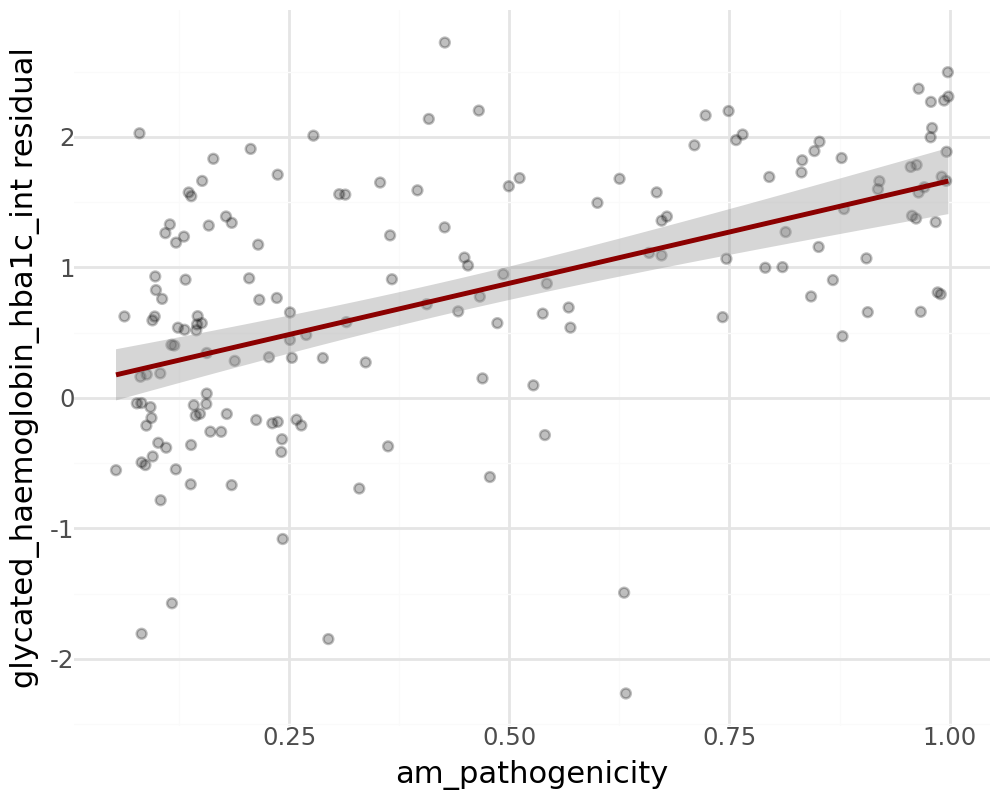

In [477]:
method = 'pearson'
annotation = 'am_pathogenicity'
gene_name = 'GCK'
phenotype = 'glycated_haemoglobin_hba1c_int'

sc_df = pheno_anno.filter(
    (pl.col('phenotype') == phenotype) &
    (pl.col('gene_name') == gene_name) &
    (pl.col('annotation') == annotation)
)

(
    ggplot(sc_df, aes(x='annotation_score', y='mean_pheno_value')) +
    geom_point(alpha=0.25) +
    geom_smooth(method='lm', se=True, color='darkred') +
    theme_minimal() +
    labs(
        x=f"{annotation}",
        y=f"{phenotype} residual"
    ) +
    theme(figure_size=(5, 4))
)

## Facet by LOEUF

In [353]:
gene_property = 'lof.oe_ci.upper'
# gene_property = 'cds_length'

gn = pl.read_csv(
    '/home/dnanexus/data_dir/gnomad.v4.1.constraint_metrics.tsv', 
    null_values='NA',
    separator='\t'
).filter(
    (pl.col('mane_select') == True) &
    (pl.col('transcript_type') == 'protein_coding')
).with_columns(
    pl.col(gene_property).qcut(10, labels=[f'{i}' for i in range(1, 11)]).alias(f'{gene_property}_decile')
).to_pandas()

gn

,gene,gene_id,transcript,canonical,mane_select,lof_hc_lc.obs,lof_hc_lc.exp,lof_hc_lc.possible,lof_hc_lc.oe,lof_hc_lc.mu,...,syn.oe_ci.upper,syn.z_raw,syn.z_score,constraint_flags,level,transcript_type,chromosome,cds_length,num_coding_exons,lof.oe_ci.upper_decile
0,A1BG,ENSG00000121410,ENST00000263100,True,True,45.0,43.0480,193.0,1.04540,7.063300e-07,...,1.172,-1.166000,-0.635490,[],2,protein_coding,chr19,1485,8,8
1,A1CF,ENSG00000148584,ENST00000373997,True,True,45.0,69.9620,352.0,0.64320,9.547100e-07,...,1.103,0.032727,0.017838,[],2,protein_coding,chr10,1758,11,4
2,A2M,ENSG00000175899,ENST00000318602,True,True,95.0,147.2400,745.0,0.64522,1.344500e-06,...,0.929,3.368800,1.836200,[],2,protein_coding,chr12,4422,36,4
3,A2ML1,ENSG00000166535,ENST00000299698,True,True,146.0,176.0500,881.0,0.82930,1.700700e-06,...,0.996,1.745200,0.951210,[],2,protein_coding,chr12,4362,35,5
4,A3GALT2,ENSG00000184389,ENST00000442999,True,True,41.0,26.5590,110.0,1.54380,3.376300e-07,...,1.753,-7.333400,-3.997000,"[""outlier_mis""]",2,protein_coding,chr1,1020,5,9
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17476,None,ENSG00000284024,ENST00000640019,True,True,23.0,33.3410,150.0,0.68984,9.153200e-07,...,1.075,0.716050,0.390280,[],2,protein_coding,chr10,1083,2,7
17477,None,ENSG00000285043,ENST00000338110,True,True,9.0,19.2800,89.0,0.46680,1.504500e-07,...,NaN,NaN,NaN,"[""no_exp_lof"",""no_exp_mis"",""no_exp_syn"",""no_va...",2,protein_coding,chr16,417,4,NaN
17478,None,ENSG00000286135,ENST00000652090,True,True,0.0,1.4471,8.0,0.00000,2.520600e-08,...,1.067,1.581300,0.861890,[],2,protein_coding,chr10,411,4,9
17479,None,ENSG00000286190,ENST00000568641,True,True,4.0,3.2926,20.0,1.21480,4.915500e-08,...,1.570,-2.406500,-1.311700,[],2,protein_coding,chr17,357,1,10


In [354]:
corr_lf = corr_pd.merge(
    gn[['gene_id', gene_property, f'{gene_property}_decile']], left_on='region', right_on='gene_id', how='left')

corr_lf = corr_lf.dropna()
corr_lf

,annotation,median_abs_corr,region,gene_name,phenotype,n_variants,correlation,abs_corr,gene_id,lof.oe_ci.upper,lof.oe_ci.upper_decile
0,am_pathogenicity,0.114126,ENSG00000029534,ANK1,reticulocyte_count_int,23,-0.208320,0.208320,ENSG00000029534,0.299,1
1,scaled_fitness,0.149155,ENSG00000181722,ZBTB20,alkaline_phosphatase_int,140,0.348419,0.348419,ENSG00000181722,0.300,1
2,verphylop,0.154868,ENSG00000029534,ANK1,mean_sphered_cell_volume_int,23,0.144590,0.144590,ENSG00000029534,0.299,1
3,verphylop,0.154868,ENSG00000124507,PACSIN1,weight_int,25,-0.027804,0.027804,ENSG00000124507,0.425,2
4,FoldX,0.215028,ENSG00000103449,SALL1,haematocrit_percentage_int,42,-0.193385,0.193385,ENSG00000103449,0.228,1
...,...,...,...,...,...,...,...,...,...,...,...
913,am_pathogenicity,0.114126,ENSG00000170374,SP7,alkaline_phosphatase_int,11,-0.012284,0.012284,ENSG00000170374,0.808,4
914,ddmut,0.149479,ENSG00000101191,DIDO1,leg_fat_percentage_left_int,147,-0.274612,0.274612,ENSG00000101191,0.235,1
915,fitness,0.156830,ENSG00000124507,PACSIN1,hip_circumference_int,175,-0.000480,0.000480,ENSG00000124507,0.425,2
916,RaSP,0.126806,ENSG00000136068,FLNB,standing_height_int,623,-0.091442,0.091442,ENSG00000136068,0.504,2


In [355]:
corr_lf[['region', 'phenotype', f'{gene_property}_decile']].drop_duplicates()[f'{gene_property}_decile'].value_counts(sort=True)

lof.oe_ci.upper_decile
1     22
3     11
4     10
2      9
10     2
5      0
6      0
7      0
8      0
9      0
Name: count, dtype: int64

/tmp/ipykernel_760855/1970709719.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
/home/dnanexus/deeprvat2-env/lib/python3.11/site-packages/plotnine/layer.py:284: PlotnineWarning: stat_boxplot : Removed 5 rows containing non-finite values.


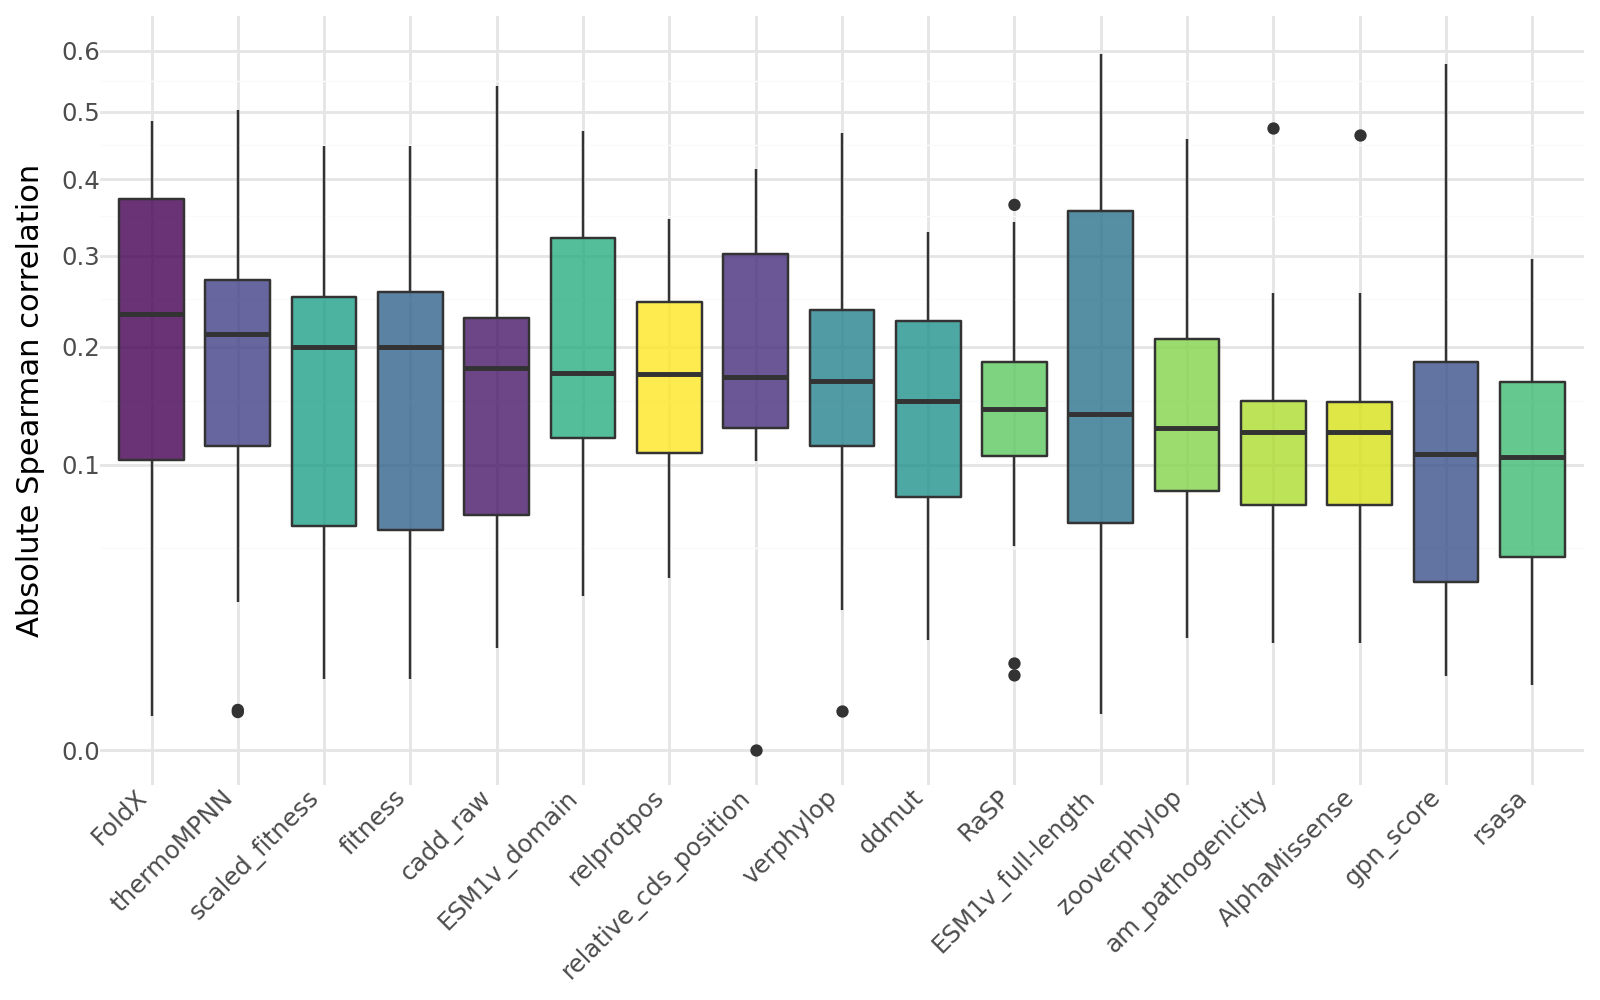

In [356]:
corr_q1 = corr_lf[corr_lf[f'{gene_property}_decile']=='1']

med_df = (
    corr_q1
    .groupby("annotation", as_index=False)
    .agg(median_abs_corr_lq=("abs_corr", "median"))
)

corr_q1 = corr_q1.merge(med_df, on='annotation')
order = corr_q1.sort_values("median_abs_corr_lq", ascending=False)["annotation"].unique()

# Plot
(
    ggplot(corr_q1, aes(x='annotation', y='abs_corr', fill='annotation')) +
    geom_boxplot(alpha=0.8) +
    theme_minimal() +
    scale_y_sqrt(limits=[0, 0.6], breaks=[b*0.1 for b in range(7)]) +
    scale_x_discrete(limits=order) +
    scale_fill_manual(values=color_dict) +
    labs(
        x='',
        y='Absolute Spearman correlation'
    ) +
    theme(
        figure_size=(8, 5),
        legend_position='none',
        axis_text_x=element_text(rotation=45, hjust=1)
    )
)

/tmp/ipykernel_760855/1725476563.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.


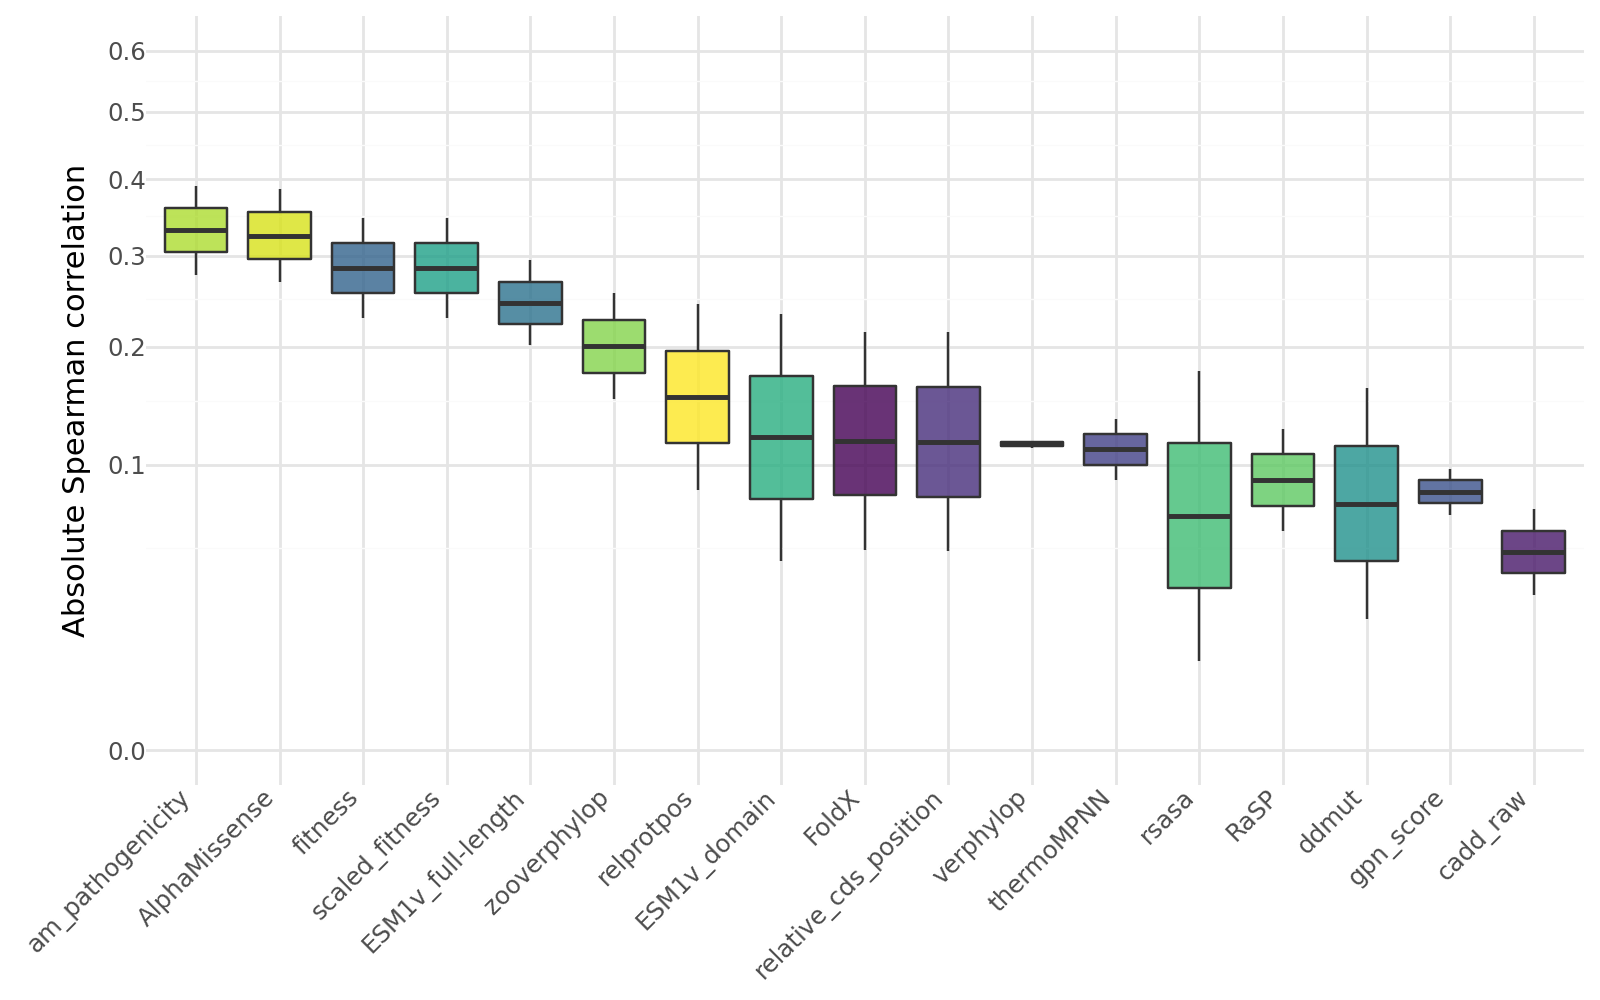

In [357]:
corr_q10 = corr_lf[corr_lf[f'{gene_property}_decile']=='10']

med_df = (
    corr_q10
    .groupby("annotation", as_index=False)
    .agg(median_abs_corr_lq=("abs_corr", "median"))
)

corr_q10 = corr_q10.merge(med_df, on='annotation')
order = corr_q10.sort_values("median_abs_corr_lq", ascending=False)["annotation"].unique()

# Plot
(
    ggplot(corr_q10, aes(x='annotation', y='abs_corr', fill='annotation')) +
    geom_boxplot(alpha=0.8) +
    theme_minimal() +
    scale_y_sqrt(limits=[0, 0.6], breaks=[b*0.1 for b in range(7)]) +
    scale_x_discrete(limits=order) +
    scale_fill_manual(values=color_dict) +
    labs(
        x='',
        y='Absolute Spearman correlation'
    ) +
    theme(
        figure_size=(8, 5),
        legend_position='none',
        axis_text_x=element_text(rotation=45, hjust=1)
    )
)

## Enrichment of true extremes in predicted extremes

In [358]:
gene_trait_df = gene_trait_df.with_columns(
    (pl.col('beta')/pl.col('beta').abs()).alias('beta_dir')
)
gene_trait_df

region,gene_id,gene_name,phenotype,trait_type,beta,beta_dir
str,str,str,str,str,f64,f64
"""ENSG00000141458""","""ENSG00000141458""","""NPC1""","""lymphocyte_percentage_int""","""continuous""",-0.218614,-1.0
"""ENSG00000179218""","""ENSG00000179218""","""CALR""","""lymphocyte_percentage_int""","""continuous""",-0.335786,-1.0
"""ENSG00000143627""","""ENSG00000143627""","""PKLR""","""red_blood_cell_erythrocyte_cou…","""continuous""",-0.251586,-1.0
"""ENSG00000244734""","""ENSG00000244734""","""HBB""","""red_blood_cell_erythrocyte_cou…","""continuous""",2.1052,1.0
"""ENSG00000141458""","""ENSG00000141458""","""NPC1""","""red_blood_cell_erythrocyte_cou…","""continuous""",0.124363,1.0
…,…,…,…,…,…,…
"""ENSG00000163554""","""ENSG00000163554""","""SPTA1""","""reticulocyte_count_int""","""continuous""",0.801084,1.0
"""ENSG00000244734""","""ENSG00000244734""","""HBB""","""reticulocyte_count_int""","""continuous""",1.04184,1.0
"""ENSG00000179218""","""ENSG00000179218""","""CALR""","""reticulocyte_count_int""","""continuous""",0.272931,1.0


In [359]:
pos_assoc= gene_trait_df.filter(pl.col('beta')>0)
pos_assoc

region,gene_id,gene_name,phenotype,trait_type,beta,beta_dir
str,str,str,str,str,f64,f64
"""ENSG00000244734""","""ENSG00000244734""","""HBB""","""red_blood_cell_erythrocyte_cou…","""continuous""",2.1052,1.0
"""ENSG00000141458""","""ENSG00000141458""","""NPC1""","""red_blood_cell_erythrocyte_cou…","""continuous""",0.124363,1.0
"""ENSG00000183765""","""ENSG00000183765""","""CHEK2""","""red_blood_cell_erythrocyte_cou…","""continuous""",0.0753436,1.0
"""ENSG00000196660""","""ENSG00000196660""","""SLC30A10""","""hdl_cholesterol_int""","""continuous""",0.0831105,1.0
"""ENSG00000166603""","""ENSG00000166603""","""MC4R""","""whole_body_fat_mass_int""","""continuous""",0.451217,1.0
…,…,…,…,…,…,…
"""ENSG00000143627""","""ENSG00000143627""","""PKLR""","""reticulocyte_count_int""","""continuous""",0.212415,1.0
"""ENSG00000163554""","""ENSG00000163554""","""SPTA1""","""reticulocyte_count_int""","""continuous""",0.801084,1.0
"""ENSG00000244734""","""ENSG00000244734""","""HBB""","""reticulocyte_count_int""","""continuous""",1.04184,1.0


In [360]:
ct_df = pheno_anno.group_by(
    ["region", "gene_name", "phenotype", "annotation"]
).agg(
    pl.col("id").count().alias("n_variants"),
)

xtm_df = pheno_anno.join(ct_df, on=["region", "gene_name", "phenotype", "annotation"], how="left")

# Restrict to postive associations
# pos_assoc= gene_trait_df.filter(pl.col('beta')>0)
# xtm_df = xtm_df.join(pos_assoc[['region', 'phenotype']], on=['region', 'phenotype'], how='inner')
xtm_df = xtm_df.join(gene_trait_df[['region', 'phenotype', 'beta_dir']], on=['region', 'phenotype'], how='inner')

xtm_df = xtm_df.with_columns(
    (pl.col("mean_pheno_value") * pl.col("beta_dir")).alias("mean_pheno_value_same_dir"),
    (pl.col("annotation_score_rank") / pl.col("n_variants")).alias("annotation_score_ptile")
)

gpn_df = xtm_df.filter(pl.col('annotation')=='gpn_score').with_columns(
    (1-pl.col('annotation_score_ptile')).alias('annotation_score_ptile'),
    pl.lit('gpn_score_rev').alias('annotation')
)

xtm_df = pl.concat([xtm_df, gpn_df])
xtm_df

id,phenotype,n_individuals,mean_pheno_value,mutant,region,annotation,annotation_score,gene_id,gene_name,trait_type,beta,mean_pheno_value_rank,annotation_score_rank,n_variants,beta_dir,mean_pheno_value_same_dir,annotation_score_ptile
str,str,u32,f32,str,str,str,f32,str,str,str,f64,u32,u32,u32,f64,f64,f64
"""chr7:93105926:C:T""","""mean_sphered_cell_volume_int""",1,0.391971,"""G58S""","""ENSG00000205413""","""cadd_raw""",3.951108,"""ENSG00000205413""","""SAMD9""","""continuous""",-0.001925,18,23,25,-1.0,-0.391971,0.92
"""chr7:93105926:C:T""","""mean_sphered_cell_volume_int""",1,0.391971,"""G58S""","""ENSG00000205413""","""am_pathogenicity""",0.3228,"""ENSG00000205413""","""SAMD9""","""continuous""",-0.001925,18,19,25,-1.0,-0.391971,0.76
"""chr7:93105926:C:T""","""mean_sphered_cell_volume_int""",1,0.391971,"""G58S""","""ENSG00000205413""","""gpn_score""",-6.25,"""ENSG00000205413""","""SAMD9""","""continuous""",-0.001925,18,5,25,-1.0,-0.391971,0.2
"""chr7:93105926:C:T""","""mean_sphered_cell_volume_int""",1,0.391971,"""G58S""","""ENSG00000205413""","""verphylop""",2.504,"""ENSG00000205413""","""SAMD9""","""continuous""",-0.001925,18,22,25,-1.0,-0.391971,0.88
"""chr7:93105926:C:T""","""mean_sphered_cell_volume_int""",1,0.391971,"""G58S""","""ENSG00000205413""","""zooverphylop""",6.284,"""ENSG00000205413""","""SAMD9""","""continuous""",-0.001925,18,23,25,-1.0,-0.391971,0.92
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""chr3:58163255:G:T""","""gamma_glutamyltransferase_int""",1,-0.074653,"""V2375F""","""ENSG00000136068""","""gpn_score_rev""",-11.65,"""ENSG00000136068""","""FLNB""","""continuous""",-0.217856,33,6,86,-1.0,0.074653,0.930233
"""chr3:58150200:A:G""","""gamma_glutamyltransferase_int""",9,-0.206462,"""I2114V""","""ENSG00000136068""","""gpn_score_rev""",-6.27,"""ENSG00000136068""","""FLNB""","""continuous""",-0.217856,27,66,86,-1.0,0.206462,0.232558
"""chr3:58163256:T:C""","""gamma_glutamyltransferase_int""",3,0.295971,"""V2375A""","""ENSG00000136068""","""gpn_score_rev""",-10.1,"""ENSG00000136068""","""FLNB""","""continuous""",-0.217856,53,18,86,-1.0,-0.295971,0.790698


In [361]:
pred_cutoff = 0.1
xtm_df = xtm_df.with_columns(
        (pl.col("annotation_score_ptile") <= pred_cutoff).alias("low_predicted"),
        (pl.col("annotation_score_ptile") >= 1 - pred_cutoff).alias("high_predicted"),
)

enr_df_list = []
for z_alpha in tqdm(range(300)):
    z_score = z_alpha/100
    pr_temp = xtm_df.filter(
        (pl.col("mean_pheno_value") >= z_score)
    ).group_by(
        ["annotation", "region", "phenotype"]
    ).agg(
        (pl.count().alias("high_true")),
        (pl.col("high_predicted").sum()).alias("high_correct"),
        
    ).with_columns(
        (pl.col("high_correct") / pl.col("high_true")).alias("high_enrichment"),
        pl.lit(z_score).alias('z_score')
    )

    enr_df_list.append(pr_temp)

enr_df = pl.concat(enr_df_list)
enr_df

  0%|          | 0/300 [00:00<?, ?it/s]/tmp/ipykernel_760855/1331981619.py:15: DeprecationWarning: `pl.count()` is deprecated. Please use `pl.len()` instead.
(Deprecated in version 0.20.5)
100%|██████████| 300/300 [00:00<00:00, 453.55it/s]


annotation,region,phenotype,high_true,high_correct,high_enrichment,z_score
str,str,str,u32,u32,f64,f64
"""ESM1v_full-length""","""ENSG00000163554""","""high_light_scatter_reticulocyt…",63,7,0.111111,0.0
"""relative_cds_position""","""ENSG00000101191""","""body_mass_index_bmi_int""",8,2,0.25,0.0
"""gpn_score_rev""","""ENSG00000103449""","""haemoglobin_concentration_int""",3,0,0.0,0.0
"""relative_cds_position""","""ENSG00000035928""","""standing_height_int""",12,1,0.083333,0.0
"""ESM1v_domain""","""ENSG00000165702""","""eosinophill_percentage_int""",56,8,0.142857,0.0
…,…,…,…,…,…,…
"""verphylop""","""ENSG00000124507""","""weight_int""",1,0,0.0,2.99
"""gpn_score_rev""","""ENSG00000124507""","""weight_int""",1,0,0.0,2.99
"""fitness""","""ENSG00000124507""","""weight_int""",7,0,0.0,2.99


In [362]:
annos_to_keep = [
    # 'zoopriphylop',
 'verphylop',
#  'relprotpos',
#  'mamphcons',
 'zooverphylop',
#  'mamphylop',
 'gpn_score',
 'gpn_score_rev',
 'relative_cds_position',
 'esmscoremissense',
#  'priphylop',
 'cadd_raw',
#  'priphcons',
#  'af_ukb',
#  'verphcons',
 'am_pathogenicity'
 ]

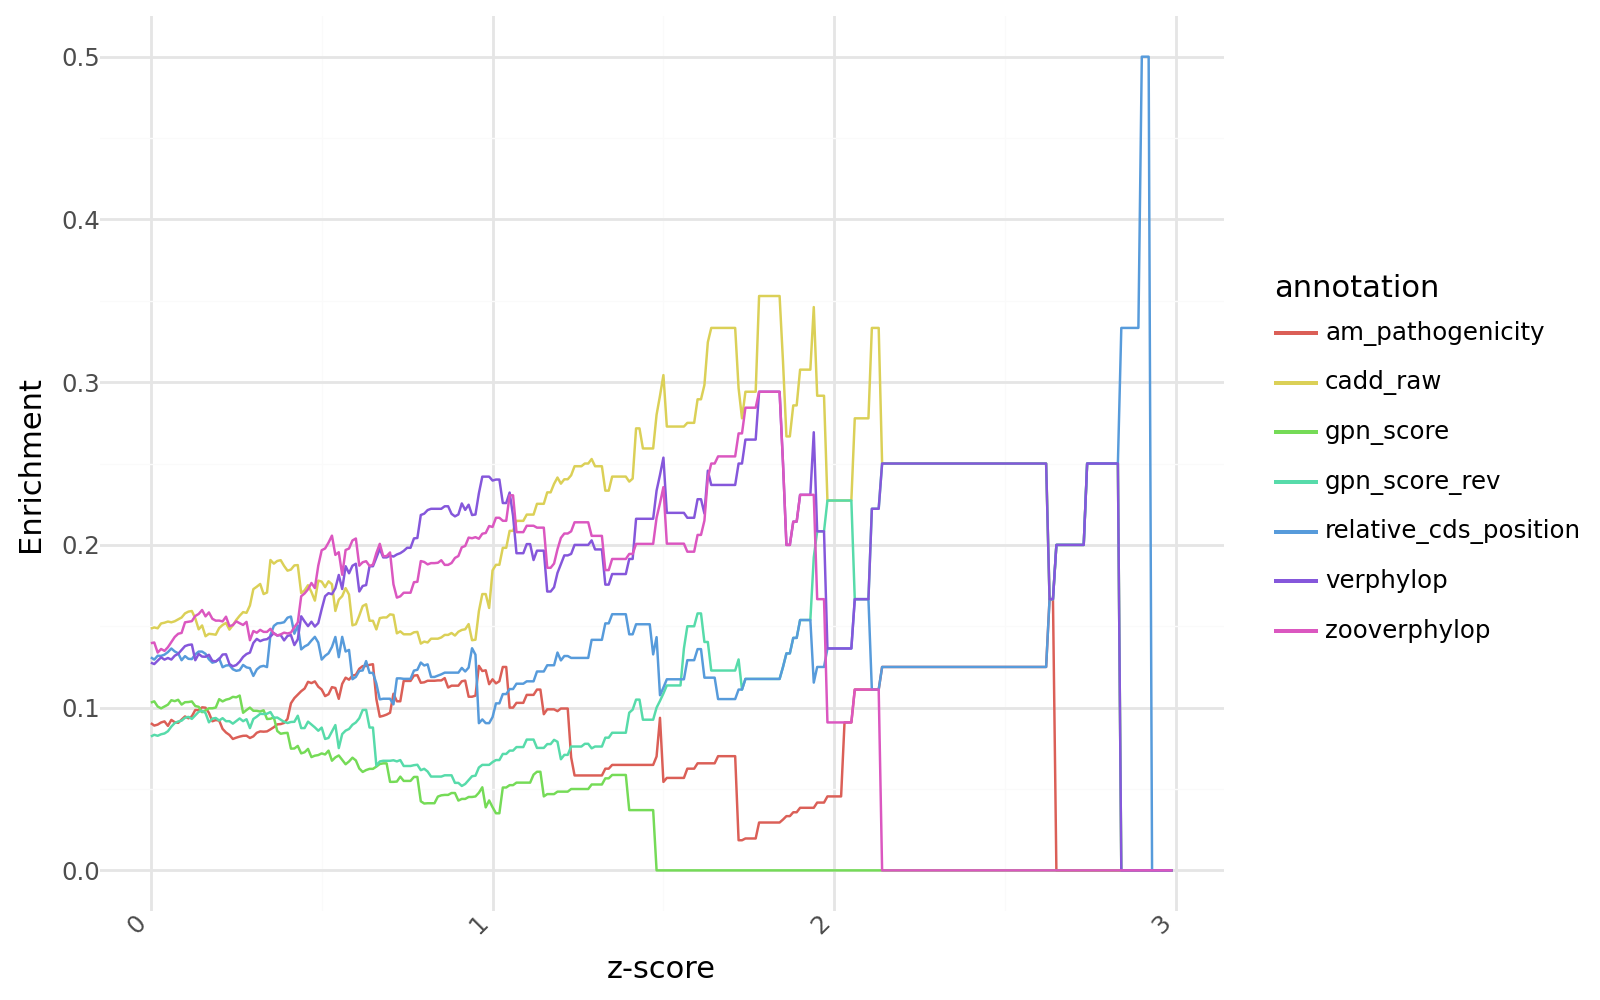

In [363]:
plot_df = enr_df.group_by('annotation', 'z_score').agg(pl.col('high_enrichment').mean())

(
    ggplot(plot_df.filter(pl.col('annotation').is_in(annos_to_keep)), aes(x='z_score', y='high_enrichment', color='annotation')) +
    geom_line() +
    # theme_538() +
    theme_minimal() +
    # scale_color_manual(values=color_dict) +
    labs(
        x='z-score',
        y='Enrichment'
    ) +
    theme(
        figure_size=(8, 5),
        # legend_position='none',
        axis_text_x=element_text(rotation=45, hjust=1)
    )
)